<a href="https://colab.research.google.com/github/PrantoMondol11/Machine-learning-/blob/main/Adaboost_HyperParameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [3]:
np.random.seed(42)

In [4]:
X,y=make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42 )

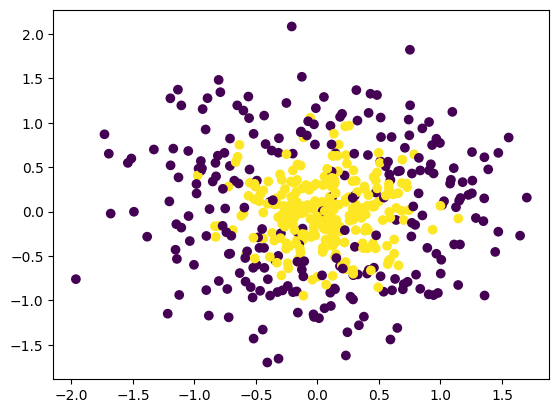

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
clf=AdaBoostClassifier()

In [7]:
np.mean(cross_val_score(clf,X,y,scoring="accuracy",cv=10))

np.float64(0.812)

In [8]:
clf.fit(X,y)

AdaBoostClassifier()

<Axes: >

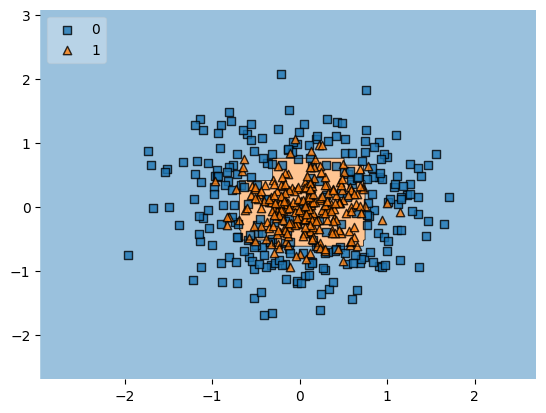

In [9]:
plot_decision_regions(X,y,clf,legend=2)

In [10]:
clf2=AdaBoostClassifier(n_estimators=1)

In [11]:
np.mean(cross_val_score(clf2,X,y,scoring="accuracy",cv=10))

np.float64(0.5660000000000001)

<Axes: >

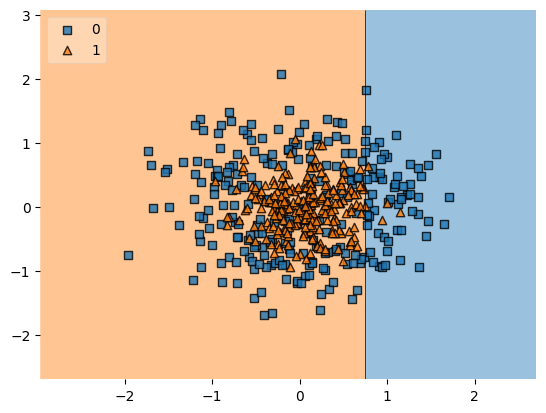

In [12]:
clf2.fit(X,y)
plot_decision_regions(X,y,clf2,legend=2)

In [14]:
from sklearn.model_selection import GridSearchCV
grid=dict()
grid["n_estimators"]=[10,50,100,500]
grid["learning_rate"]=[0.0001,0.001,0.01,0.1,1.0]
grid["algorithm"]=['SAMME','SAMME.R']

grid_search=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=grid,n_jobs=-1,cv=10,scoring="accuracy")
grid_result=grid_search.fit(X,y)

print(f"Best accuracy : {grid_result.best_score_} /n params: {grid_result.best_params_}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
200 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

Best accuracy : 0.8320000000000001 /n params: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 500}
